# 04 — Active Learning Sampling (rewritten)

This notebook rebuilds the **property-free exploratory active learning** sampler in composition space and adds the diagnostics needed to understand why the uncertainty may not decrease.

## What was going wrong in the previous notebook

The previous implementation used the RBF length scale equal to the **median nearest-neighbour distance**. In this problem that can make the kernel **too local**. Then most candidate points have almost zero covariance with the selected set, so the predictive variance stays close to 1 for nearly all points.

In other words, the sampler is mathematically valid, but the kernel can be so narrow that the uncertainty does not propagate through the pool.

## What this notebook changes

1. Build the same independent coordinates:
   - `x_CO2`
   - normalized impurity fractions `z_i = x_i / (1 - x_CO2)`

2. Min-max scale the inputs.

3. Diagnose the pool geometry:
   - nearest-neighbour distance distribution
   - random pairwise distance distribution

4. Test several RBF length scales:
   - `1 × median NN distance`
   - `2 × median NN distance`
   - `5 × median NN distance`
   - `10 × median NN distance`

5. Compare uncertainty decay curves before choosing the final length scale.

6. Use a slightly larger initial seed set and an optional **farthest-point** initializer.

7. Save the final selected subsets for budgets:
   - 20
   - 40
   - 60
   - 80
   - 100

This notebook does **not** run cDFT. It only performs the active-learning subset selection.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import MinMaxScaler

In [2]:
# ------------------------------
# User settings
# ------------------------------
POOL_PATH   = Path("AL_POOL/composition_pool.csv")
OUTPUT_DIR  = Path("AL_Sampling_Rewrite")
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

IMPURITY_COLS = ["H2", "Ar", "N2", "CH4", "O2", "CO", "H2S"]

BUDGETS      = [20, 40, 60, 80, 100]
N_INIT_SEEDS = 5
BASE_SEED    = 770077

SIGMA_F2 = 1.0
SIGMA_N2 = 1e-8

# Length-scale sweep relative to median nearest-neighbour distance
L_MULTIPLIERS = [1.0, 2.0, 3.0, 5.0, 10.0]

# Final chosen multiplier after inspecting the sweep
FINAL_L_MULTIPLIER = 5.0

# Seed strategy: "random" or "farthest"
SEED_STRATEGY = "farthest"

pool = pd.read_csv(POOL_PATH)
print(f"Pool size: {len(pool):,}")
display(pool.head())


Pool size: 1,000


,feed_id,feed_source,template_name,mixture_size,active_components,CO2,H2,Ar,N2,CH4,O2,CO,H2S
0,0,Random (Dirichlet),dirichlet,4,"CO2,Ar,N2,H2S",0.97,0.000000,0.005316,0.00397,0.000000,0.000000,0.000000,0.020713
1,1,Random (Dirichlet),dirichlet,3,"CO2,Ar,O2",0.98,0.000000,0.000874,0.00000,0.000000,0.019126,0.000000,0.000000
2,2,Random (Dirichlet),dirichlet,6,"CO2,H2,Ar,CH4,O2,CO",0.95,0.007078,0.008244,0.00000,0.001661,0.029273,0.003745,0.000000
3,3,Random (Dirichlet),dirichlet,5,"CO2,Ar,O2,CO,H2S",0.95,0.000000,0.019822,0.00000,0.000000,0.004980,0.008938,0.016261
4,4,Random (Dirichlet),dirichlet,5,"CO2,H2,CH4,CO,H2S",0.95,0.012668,0.000000,0.00000,0.009235,0.000000,0.010824,0.017274


In [3]:
# ------------------------------
# Step 1: independent composition coordinates
# ------------------------------
co2 = pool["CO2"].to_numpy()
x_imp_total = 1.0 - co2

# normalized impurity fractions
Z_imp = pool[IMPURITY_COLS].to_numpy() / np.clip(x_imp_total[:, None], 1e-12, None)

# feature vector = [x_CO2, z_H2, z_Ar, ..., z_H2S]
X_raw = np.column_stack([co2, Z_imp])

print("X_raw shape:", X_raw.shape)
print("Check impurity fractions sum to ~1:", np.max(np.abs(Z_imp.sum(axis=1) - 1.0)))


X_raw shape: (1000, 8)
Check impurity fractions sum to ~1: 4.083400284571326e-13


In [4]:
# ------------------------------
# Step 2: min-max scaling
# ------------------------------
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_raw)

print("Scaled min/max:", X_scaled.min(), X_scaled.max())


Scaled min/max: 0.0 1.0


Median nearest-neighbour distance = 0.145215
Median random pairwise distance   = 0.937484
Mean random pairwise distance     = 0.928522


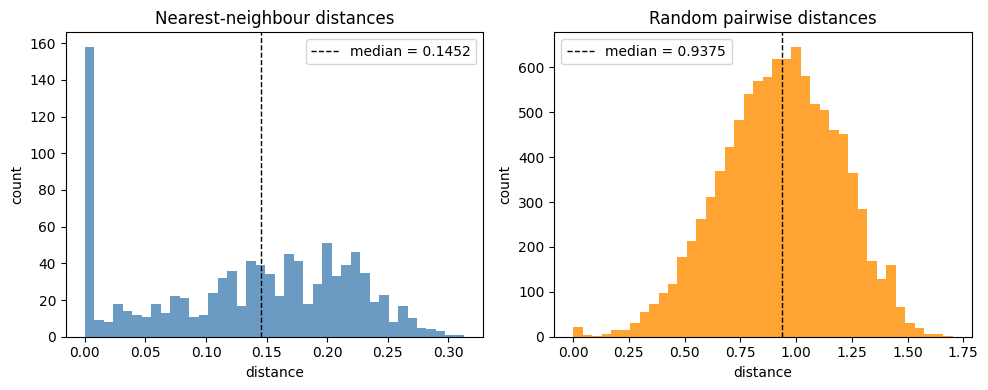

In [5]:
# ------------------------------
# Step 3: pool-geometry diagnostics
# ------------------------------
# nearest-neighbour distances
nbrs = NearestNeighbors(n_neighbors=2).fit(X_scaled)
dists, _ = nbrs.kneighbors(X_scaled)
nn_dists = dists[:, 1]
median_nn = float(np.median(nn_dists))

print(f"Median nearest-neighbour distance = {median_nn:.6f}")

# random pairwise distances for comparison
rng = np.random.default_rng(BASE_SEED)
n_pairs = min(10000, len(X_scaled) * 10)
idx_a = rng.integers(0, len(X_scaled), size=n_pairs)
idx_b = rng.integers(0, len(X_scaled), size=n_pairs)
pair_dists = np.linalg.norm(X_scaled[idx_a] - X_scaled[idx_b], axis=1)

print(f"Median random pairwise distance   = {np.median(pair_dists):.6f}")
print(f"Mean random pairwise distance     = {np.mean(pair_dists):.6f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(nn_dists, bins=40, color="steelblue", alpha=0.8)
axes[0].axvline(median_nn, color="black", ls="--", lw=1, label=f"median = {median_nn:.4f}")
axes[0].set_title("Nearest-neighbour distances")
axes[0].set_xlabel("distance")
axes[0].set_ylabel("count")
axes[0].legend()

axes[1].hist(pair_dists, bins=40, color="darkorange", alpha=0.8)
axes[1].axvline(np.median(pair_dists), color="black", ls="--", lw=1, label=f"median = {np.median(pair_dists):.4f}")
axes[1].set_title("Random pairwise distances")
axes[1].set_xlabel("distance")
axes[1].set_ylabel("count")
axes[1].legend()

plt.tight_layout()
plt.show()


In [6]:
# ------------------------------
# Kernel and AL utilities
# ------------------------------
def rbf_kernel(A, B, length_scale, sigma_f2=1.0):
    diff = A[:, None, :] - B[None, :, :]
    sq = np.sum(diff**2, axis=-1)
    return sigma_f2 * np.exp(-sq / (2.0 * length_scale**2))

def choose_initial_seeds(X, n_init, seed=0, strategy="random"):
    rng = np.random.default_rng(seed)
    n = len(X)

    if strategy == "random":
        return list(rng.choice(n, size=n_init, replace=False))

    if strategy == "farthest":
        # start from one random point, then greedily pick the farthest point
        first = int(rng.integers(0, n))
        selected = [first]

        while len(selected) < n_init:
            sel = X[selected]
            d = np.linalg.norm(X[:, None, :] - sel[None, :, :], axis=-1)
            min_d = d.min(axis=1)
            min_d[selected] = -np.inf
            selected.append(int(np.argmax(min_d)))
        return selected

    raise ValueError("strategy must be 'random' or 'farthest'")

def predictive_variance(X, selected_idx, remaining_idx, length_scale, sigma_f2=1.0, sigma_n2=1e-8):
    XS = X[selected_idx]
    XP = X[remaining_idx]

    K_ss = rbf_kernel(XS, XS, length_scale, sigma_f2=sigma_f2)
    K_ss = K_ss + sigma_n2 * np.eye(len(selected_idx))
    K_ps = rbf_kernel(XP, XS, length_scale, sigma_f2=sigma_f2)

    # Cholesky-based variance computation
    L = np.linalg.cholesky(K_ss)
    V = np.linalg.solve(L, K_ps.T)  # shape (|S|, |P|)
    var = sigma_f2 - np.sum(V * V, axis=0)
    var = np.maximum(var, 0.0)  # guard against tiny negative numerical values
    return var

def run_active_learning(X, budgets, length_scale, n_init=5, seed=0, seed_strategy="random",
                        sigma_f2=1.0, sigma_n2=1e-8):
    n = len(X)
    budgets = sorted(budgets)
    max_budget = max(budgets)

    selected = choose_initial_seeds(X, n_init=n_init, seed=seed, strategy=seed_strategy)
    selected_set = set(selected)
    remaining = [i for i in range(n) if i not in selected_set]

    log_rows = []
    budget_subsets = {}

    while len(selected) < max_budget:
        var = predictive_variance(X, selected, remaining, length_scale, sigma_f2=sigma_f2, sigma_n2=sigma_n2)
        j = int(np.argmax(var))
        next_idx = remaining[j]
        next_var = float(var[j])

        selected.append(next_idx)
        selected_set.add(next_idx)
        remaining.pop(j)

        log_rows.append({
            "S_size": len(selected),
            "pool_idx": next_idx,
            "sigma2": next_var
        })

        if len(selected) in budgets:
            budget_subsets[len(selected)] = list(selected)

    return pd.DataFrame(log_rows), budget_subsets


In [7]:
# ------------------------------
# Step 4: length-scale sweep
# ------------------------------
sweep_results = {}

for mult in L_MULTIPLIERS:
    l_scale = mult * median_nn
    log_df, subsets = run_active_learning(
        X_scaled,
        budgets=BUDGETS,
        length_scale=l_scale,
        n_init=N_INIT_SEEDS,
        seed=BASE_SEED,
        seed_strategy=SEED_STRATEGY,
        sigma_f2=SIGMA_F2,
        sigma_n2=SIGMA_N2,
    )
    sweep_results[mult] = {"log": log_df, "subsets": subsets, "l_scale": l_scale}
    print(f"Multiplier {mult:>4}: l = {l_scale:.6f}, final sigma2 = {log_df['sigma2'].iloc[-1]:.6f}")


Multiplier  1.0: l = 0.145215, final sigma2 = 0.998673
Multiplier  2.0: l = 0.290430, final sigma2 = 0.605544
Multiplier  3.0: l = 0.435645, final sigma2 = 0.162220
Multiplier  5.0: l = 0.726075, final sigma2 = 0.013010
Multiplier 10.0: l = 1.452151, final sigma2 = 0.000192


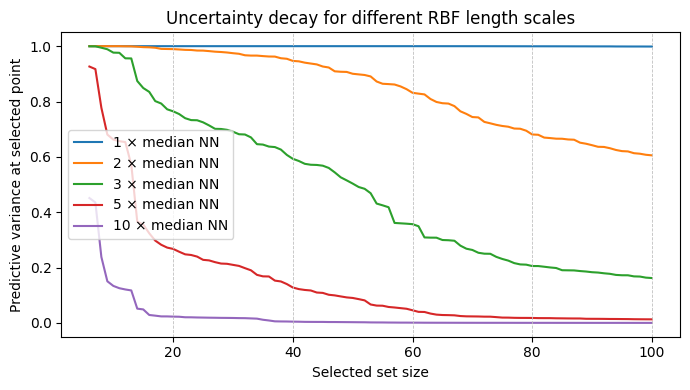

In [8]:
# ------------------------------
# Plot uncertainty decay for the length-scale sweep
# ------------------------------
fig, ax = plt.subplots(figsize=(7, 4))

for mult in L_MULTIPLIERS:
    log_df = sweep_results[mult]["log"]
    ax.plot(log_df["S_size"], log_df["sigma2"], lw=1.5, label=f"{mult:g} × median NN")

for b in BUDGETS:
    ax.axvline(b, ls="--", lw=0.6, color="silver")

ax.set_xlabel("Selected set size")
ax.set_ylabel("Predictive variance at selected point")
ax.set_title("Uncertainty decay for different RBF length scales")
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
# ------------------------------
# Save final AL subsets to CSV  (FINAL_L_MULTIPLIER)
# Format mirrors Random_Sampling / Stratified_Sampling files
# ------------------------------
POOL_COLS = ["pool_idx", "feed_id", "feed_source", "template_name",
             "mixture_size", "active_components",
             "CO2", "H2", "Ar", "N2", "CH4", "O2", "CO", "H2S"]

final_subs_save = sweep_results[FINAL_L_MULTIPLIER]["subsets"]
final_log_save  = sweep_results[FINAL_L_MULTIPLIER]["log"]

for b, idx_list in sorted(final_subs_save.items()):
    subset_df = pool.iloc[idx_list].copy().reset_index(drop=True)
    subset_df.insert(0, "pool_idx", idx_list)
    out_path = OUTPUT_DIR / f"N{b:03d}_al.csv"
    subset_df[POOL_COLS].to_csv(out_path, index=False)
    print(f"Saved {len(subset_df):>3} rows → {out_path}")

log_path = OUTPUT_DIR / "selection_log.csv"
final_log_save.to_csv(log_path, index=False)
print(f"Saved selection log  → {log_path}")


Saved  20 rows → AL_Sampling_Rewrite/N020_al.csv
Saved  40 rows → AL_Sampling_Rewrite/N040_al.csv
Saved  60 rows → AL_Sampling_Rewrite/N060_al.csv
Saved  80 rows → AL_Sampling_Rewrite/N080_al.csv
Saved 100 rows → AL_Sampling_Rewrite/N100_al.csv
Saved selection log  → AL_Sampling_Rewrite/selection_log.csv


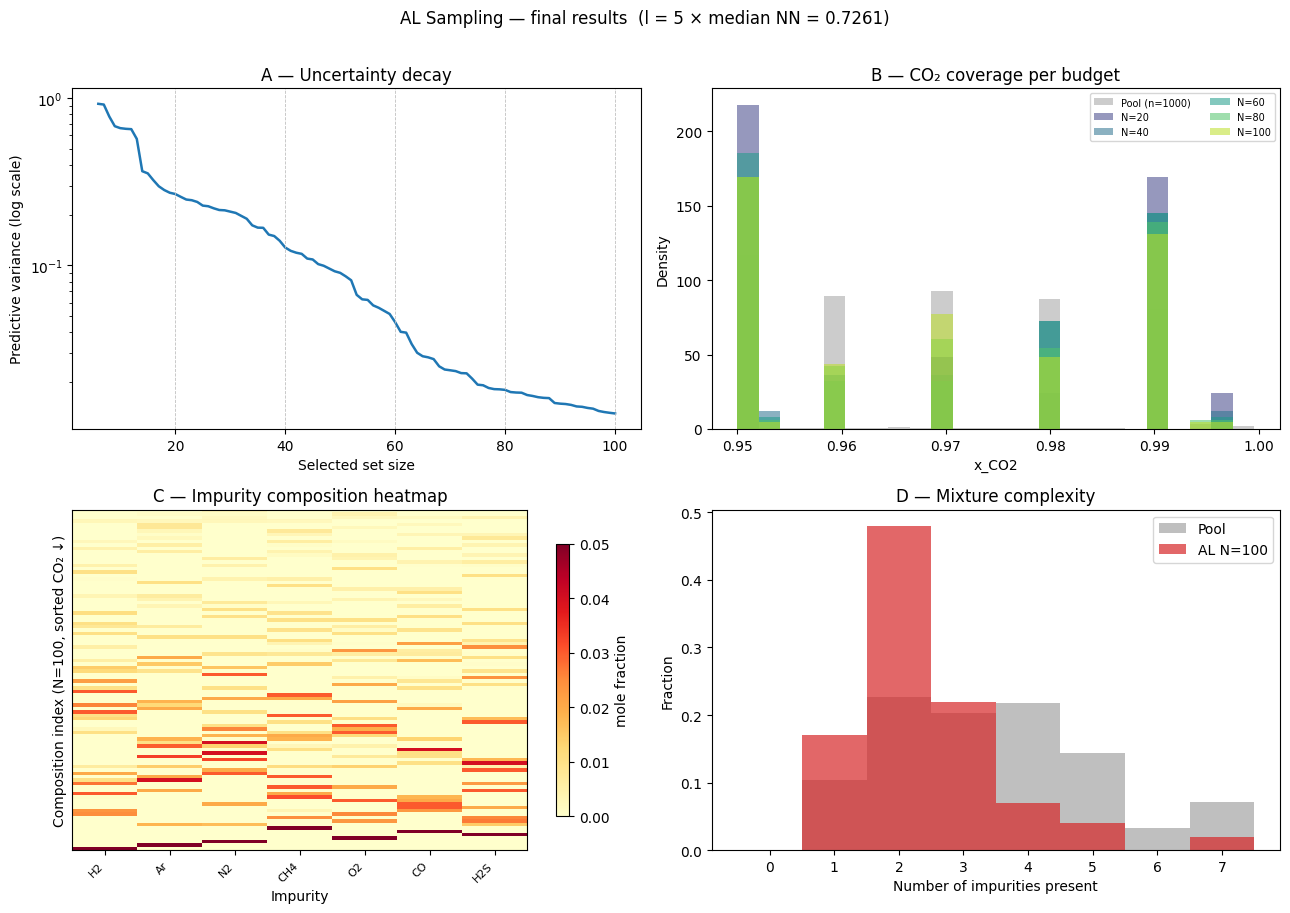

Saved → AL_Sampling_Rewrite/final_visualization.png


In [10]:
# ------------------------------
# Final visualization  (FINAL_L_MULTIPLIER)
# ------------------------------
final_log  = sweep_results[FINAL_L_MULTIPLIER]["log"]
final_subs = sweep_results[FINAL_L_MULTIPLIER]["subsets"]
l_chosen   = sweep_results[FINAL_L_MULTIPLIER]["l_scale"]
max_b      = max(b for b in BUDGETS if b in final_subs)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle(
    f"AL Sampling — final results  (l = {FINAL_L_MULTIPLIER:g} × median NN = {l_chosen:.4f})",
    fontsize=12, y=1.01,
)

# ── A: uncertainty decay ──────────────────────────────────────────────────
ax = axes[0, 0]
ax.semilogy(final_log["S_size"], final_log["sigma2"], lw=1.8, color="#1f77b4")
for b in BUDGETS:
    ax.axvline(b, ls="--", lw=0.6, color="silver")
ax.set_xlabel("Selected set size")
ax.set_ylabel("Predictive variance (log scale)")
ax.set_title("A — Uncertainty decay")

# ── B: CO2 distribution per budget ───────────────────────────────────────
ax = axes[0, 1]
co2_pool = pool["CO2"].values
bins = np.linspace(co2_pool.min(), co2_pool.max(), 25)
ax.hist(co2_pool, bins=bins, alpha=0.4, color="grey", density=True, label="Pool (n=1000)")
colors_b = plt.cm.viridis(np.linspace(0.2, 0.9, len(BUDGETS)))
for b, col in zip(BUDGETS, colors_b):
    if b in final_subs:
        sel_co2 = pool.iloc[final_subs[b]]["CO2"].values
        ax.hist(sel_co2, bins=bins, alpha=0.55, color=col, density=True, label=f"N={b}")
ax.set_xlabel("x_CO2")
ax.set_ylabel("Density")
ax.set_title("B — CO₂ coverage per budget")
ax.legend(fontsize=7, ncol=2)

# ── C: impurity composition heatmap (final budget) ───────────────────────
ax = axes[1, 0]
sel_rows    = pool.iloc[final_subs[max_b]]
order       = sel_rows["CO2"].argsort()[::-1].values          # sort high→low CO2
imp_matrix  = sel_rows[IMPURITY_COLS].values[order]
im = ax.imshow(imp_matrix, aspect="auto", cmap="YlOrRd",
               interpolation="nearest", vmin=0)
ax.set_yticks([])
ax.set_xticks(range(len(IMPURITY_COLS)))
ax.set_xticklabels(IMPURITY_COLS, rotation=45, ha="right", fontsize=8)
ax.set_xlabel("Impurity")
ax.set_ylabel(f"Composition index (N={max_b}, sorted CO₂ ↓)")
ax.set_title("C — Impurity composition heatmap")
fig.colorbar(im, ax=ax, shrink=0.8, label="mole fraction")

# ── D: mixture complexity distribution ───────────────────────────────────
ax = axes[1, 1]
pool_complexity = (pool[IMPURITY_COLS] > 0).sum(axis=1).values
sel_complexity  = (pool.iloc[final_subs[max_b]][IMPURITY_COLS] > 0).sum(axis=1).values
bins_k = np.arange(0, pool_complexity.max() + 2) - 0.5
ax.hist(pool_complexity, bins=bins_k, alpha=0.5, color="grey",    density=True, label="Pool")
ax.hist(sel_complexity,  bins=bins_k, alpha=0.7, color="#d62728", density=True, label=f"AL N={max_b}")
ax.set_xlabel("Number of impurities present")
ax.set_ylabel("Fraction")
ax.set_xticks(range(0, int(pool_complexity.max()) + 1))
ax.set_title("D — Mixture complexity")
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "final_visualization.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {OUTPUT_DIR}/final_visualization.png")


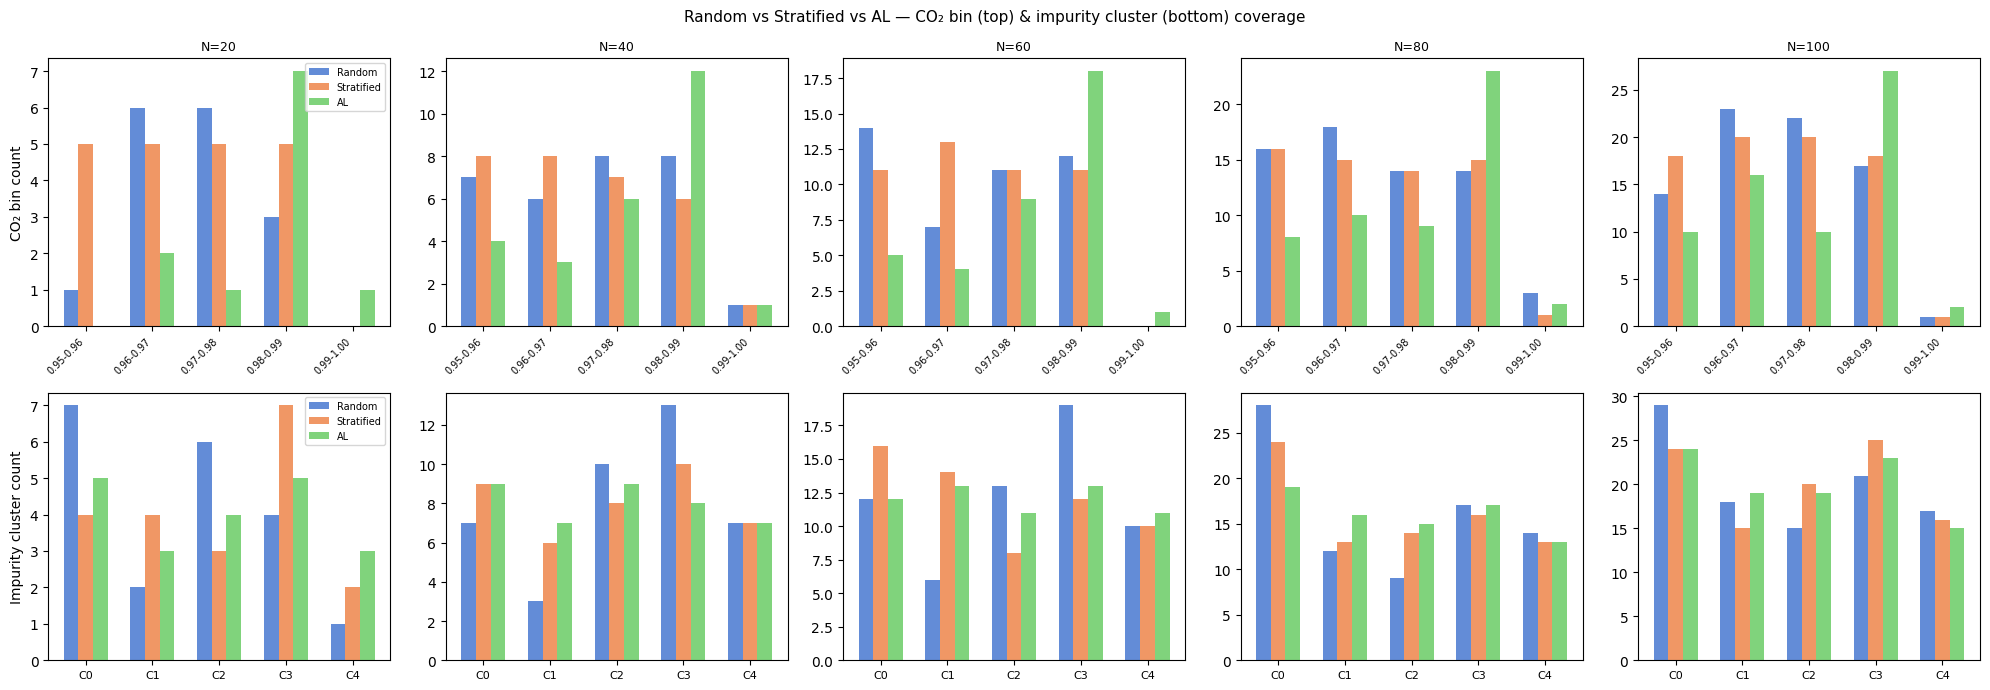

Saved → AL_Sampling_Rewrite/coverage_3methods.png


In [11]:
# ------------------------------
# Coverage comparison: Random vs Stratified vs AL
# CO2 bin (top row) & impurity cluster (bottom row), one panel per budget
# ------------------------------
from sklearn.cluster import KMeans

# ── CO2 bins ──────────────────────────────────────────────────────────────
co2_bin_edges  = [0.95, 0.96, 0.97, 0.98, 0.99, 1.00]
co2_bin_labels = ["0.95-0.96", "0.96-0.97", "0.97-0.98", "0.98-0.99", "0.99-1.00"]
pool["co2_bin"] = pd.cut(pool["CO2"], bins=co2_bin_edges, right=True, labels=co2_bin_labels)

# ── impurity clusters (k-means on normalised impurity fractions) ──────────
N_CLUSTERS = 5
km = KMeans(n_clusters=N_CLUSTERS, random_state=BASE_SEED, n_init=10)
pool["cluster"] = km.fit_predict(Z_imp)
cluster_labels  = [f"C{k}" for k in range(N_CLUSTERS)]

# ── load Random & Stratified trial_00 CSVs ────────────────────────────────
RAND_DIR  = Path("Random_Sampling")
STRAT_DIR = Path("Stratified_Sampling")

def load_trial0_idx(base_dir, budget):
    df = pd.read_csv(base_dir / f"N{budget:03d}" / "trial_00.csv")
    return df["pool_idx"].tolist()

rand_subs  = {b: load_trial0_idx(RAND_DIR,  b) for b in BUDGETS}
strat_subs = {b: load_trial0_idx(STRAT_DIR, b) for b in BUDGETS}
al_subs    = sweep_results[FINAL_L_MULTIPLIER]["subsets"]

# ── plot ──────────────────────────────────────────────────────────────────
methods = [
    ("Random",     rand_subs,  "#4878d0"),
    ("Stratified", strat_subs, "#ee854a"),
    ("AL",         al_subs,    "#6acc65"),
]
n_methods = len(methods)
x = np.arange(5)
w = 0.22
offsets = np.linspace(-(n_methods - 1) / 2, (n_methods - 1) / 2, n_methods) * w

fig, axes = plt.subplots(2, len(BUDGETS), figsize=(4 * len(BUDGETS), 7))
fig.suptitle(
    "Random vs Stratified vs AL — CO₂ bin (top) & impurity cluster (bottom) coverage",
    fontsize=11,
)

for col, b in enumerate(BUDGETS):
    # top: CO2 bin counts
    ax = axes[0, col]
    for (label, subs, color), off in zip(methods, offsets):
        if b not in subs:
            continue
        counts = (pool.iloc[subs[b]]["co2_bin"]
                  .value_counts()
                  .reindex(co2_bin_labels, fill_value=0))
        ax.bar(x + off, counts.values, width=w, color=color, alpha=0.85, label=label)
    ax.set_xticks(x)
    ax.set_xticklabels(co2_bin_labels, rotation=45, ha="right", fontsize=7)
    ax.set_title(f"N={b}", fontsize=9)
    if col == 0:
        ax.set_ylabel("CO₂ bin count")
        ax.legend(fontsize=7)

    # bottom: impurity cluster counts
    ax = axes[1, col]
    for (label, subs, color), off in zip(methods, offsets):
        if b not in subs:
            continue
        counts = (pool.iloc[subs[b]]["cluster"]
                  .value_counts()
                  .sort_index()
                  .reindex(range(N_CLUSTERS), fill_value=0))
        ax.bar(x + off, counts.values, width=w, color=color, alpha=0.85, label=label)
    ax.set_xticks(x)
    ax.set_xticklabels(cluster_labels, fontsize=8)
    if col == 0:
        ax.set_ylabel("Impurity cluster count")
        ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "coverage_3methods.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {OUTPUT_DIR}/coverage_3methods.png")
